# Introduction to Neural Networks

In this activity, you will implement a simple feedforward neural network from scratch using Python. We will use the popular MNIST dataset, which consists of handwritten digits, to train our neural network.

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn


## MNIST dataset

This is a classic dataset in machine learning, consisting of 60,000 training images and 10,000 test images of handwritten digits (0-9). Each image is a 28x28 pixel grayscale image, which can be flattened into a 784-dimensional vector for input into our neural network. The goal is to classify each image into one of the 10 digit classes. The following code will load them into memory.

In [76]:
transform = transforms.ToTensor()

# MNIST dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Test set
test_dataset = datasets.MNIST(
    root='./data',
    train=False,          # Load test set
    download=True,
    transform=transform
)

train_size = 50000
val_size = 10000
# Split the training dataset into train and validation sets.
train_set, val_set = random_split(train_dataset, [train_size, val_size])

print("train:", len(train_set), "val:", len(val_set), "test:", len(test_dataset))


train: 50000 val: 10000 test: 10000


In [77]:
batch_size = 256
#
# train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True)
# val_loader = DataLoader(val_set, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

We can also use matplotlib to visualize the images in the dataset. Each image is a 28x28 pixel grayscale image, which can be displayed using the `imshow` function from matplotlib.

In [78]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

Every time you run this cell, a random number from the training set will be displayed. You can run it multiple times to see different images from the dataset.

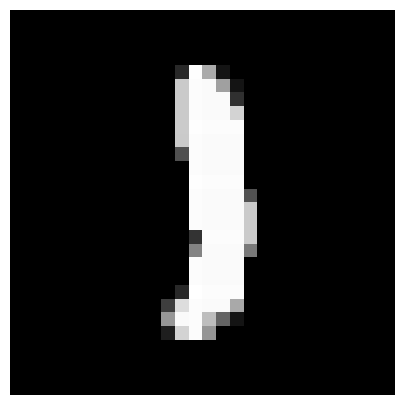

'Label: 1'

In [79]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Defining the Neural Network

In [80]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_size=784, hidden_size=200, output_size=10):
        super(FeedForwardNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

In [81]:
class DeepFeedForwardNN(nn.Module):
    def __init__(self, input_size=784, hidden_size_1=256, hidden_size_2=128, output_size=10):
        super(DeepFeedForwardNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size_1)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size_1, hidden_size_2)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(hidden_size_2, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        return x

## Training the Neural Network

In [82]:
# model = FeedForwardNN(input_size=784, hidden_size=200, output_size=10)
#
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#
# loss_func = nn.CrossEntropyLoss()

In [83]:
def train_model(model, train_loader, val_loader, optimizer, loss_func, num_epochs, device, config_name):

    model.to(device)

    train_losses = []
    val_losses = []
    val_accuracies = []

    print(f"\n{'='*60}")
    print(f"Training: {config_name}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = loss_func(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_accuracy = 100 * correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    print(f"\nFinal accuracy: {val_accuracies[-1]:.2f}%\n")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "final_accuracy": val_accuracies[-1],
        "model": model
    }



Dataloaders, Optimizer and loss function are defined bellow as part of the implementation of the training loop as a function.

Since those are dynamic data, we will define them inside the configuration loop.

In [84]:
configs = [
    {
        "name": "Model 1",
        "hidden_size": 200,
        "optimizer_type": "Adam",
        "lr": 0.001,
        "batch_size": 256,
        "num_epochs": 10
    },
    {
        "name": "Model 2",
        "hidden_size": 512,
        "optimizer_type": "SGD",
        "lr": 0.01,
        "batch_size": 128,
        "num_epochs": 15
    },
    {
        "name": "Model 3",
        "hidden_size_1": 256,
        "hidden_size_2": 128,
        "optimizer_type": "Adam",
        "lr": 0.0005,
        "batch_size": 64,
        "num_epochs": 20
    }
]

all_results = {}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_func = nn.CrossEntropyLoss()

for config in configs:
    # Models
    if "hidden_size_2" in config:
        model = DeepFeedForwardNN(
            input_size=784,
            hidden_size_1=config["hidden_size_1"],
            hidden_size_2=config["hidden_size_2"],
            output_size=10
        )
    else:
        model = FeedForwardNN(
            input_size=784,
            hidden_size=config["hidden_size"],
            output_size=10
        )

    # DataLoaders
    train_loader_config = DataLoader(train_set, batch_size=config["batch_size"], shuffle=True)
    val_loader_config = DataLoader(val_set, batch_size=config["batch_size"], shuffle=False)

    # Optimizer
    if config["optimizer_type"] == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=config["lr"])

    # Model training
    results = train_model(
        model=model,
        train_loader=train_loader_config,
        val_loader=val_loader_config,
        optimizer=optimizer,
        loss_func=loss_func,
        num_epochs=config["num_epochs"],
        device=device,
        config_name=config["name"]
    )

    all_results[config["name"]] = results

# Results
print("\n" + "="*60)
print("Results")
print("="*60)

for config_name, results in all_results.items():
    print(f"{config_name}")
    print(f"  Accuracy final: {results['final_accuracy']:.2f}%\n")


Training: Model 1



Epoch 1/10 | Train Loss: 0.5126 | Val Loss: 0.2872 | Val Acc: 92.02%


Epoch 2/10 | Train Loss: 0.2341 | Val Loss: 0.2147 | Val Acc: 94.00%


Epoch 3/10 | Train Loss: 0.1761 | Val Loss: 0.1716 | Val Acc: 95.09%


Epoch 4/10 | Train Loss: 0.1396 | Val Loss: 0.1488 | Val Acc: 95.72%


...

Epoch 16/20 | Train Loss: 0.0070 | Val Loss: 0.1166 | Val Acc: 97.53%


Epoch 17/20 | Train Loss: 0.0062 | Val Loss: 0.1086 | Val Acc: 97.78%


Epoch 18/20 | Train Loss: 0.0064 | Val Loss: 0.1042 | Val Acc: 97.86%


Epoch 19/20 | Train Loss: 0.0054 | Val Loss: 0.1043 | Val Acc: 98.04%


Epoch 20/20 | Train Loss: 0.0066 | Val Loss: 0.1005 | Val Acc: 97.96%

Final accuracy: 97.96%


Results
Model 1
  Accuracy final: 97.33%

Model 2
  Accuracy final: 91.48%

Model 3
  Accuracy final: 97.96%



## Testing the model